In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mingangolo/underrated/database.sqlite


In [2]:
import pandas as pd
import sqlite3
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

conn = sqlite3.connect('/kaggle/input/datasets/mingangolo/underrated/database.sqlite')

players = pd.read_sql("SELECT * FROM Player", conn)
player_attrs = pd.read_sql("SELECT * FROM Player_Attributes", conn)

# Clean
player_attrs = player_attrs.dropna(subset=['overall_rating'])
num_cols = player_attrs.select_dtypes(include='number').columns
player_attrs[num_cols] = player_attrs[num_cols].fillna(player_attrs[num_cols].median())

print("Ready!")

Ready!


In [3]:
# These stats represent real performance regardless of reputation
performance_cols = [
    'finishing', 'dribbling', 'short_passing', 'long_passing',
    'ball_control', 'acceleration', 'sprint_speed', 'stamina',
    'strength', 'reactions', 'vision', 'positioning'
]

# Get latest attributes per player
latest = player_attrs.sort_values('date').groupby('player_api_id').last().reset_index()

# Calculate average performance score from key stats
latest['performance_score'] = latest[performance_cols].mean(axis=1).round(1)

# Merge with player names
latest = latest.merge(players, on='player_api_id')

# Calculate underrated score
# High performance + low overall rating = underrated
latest['underrated_score'] = (latest['performance_score'] - latest['overall_rating']).round(1)

# Keep only relevant columns
result = latest[['player_name', 'overall_rating', 'performance_score', 'underrated_score']].copy()

print(result.sort_values('underrated_score', ascending=False).head(10))

                player_name  overall_rating  performance_score  \
5513         Matt Thornhill            58.0               65.6   
9050                 Stenio            59.0               66.3   
9813        Phillip Roberts            59.0               66.2   
6116      Radoslaw Pruchnik            57.0               63.9   
9423            El-Hadji Ba            57.0               63.7   
6072   Ridge Mickael Mobulu            52.0               58.3   
8473   Dzikamai Andre Gwaze            55.0               61.2   
9451  Krzysztof Danielewicz            57.0               63.1   
7270         Abdulla Fatadi            57.0               62.8   
4526                 Filipe            55.0               60.8   

      underrated_score  
5513               7.6  
9050               7.3  
9813               7.2  
6116               6.9  
9423               6.7  
6072               6.3  
8473               6.2  
9451               6.1  
7270               5.8  
4526               5.8 

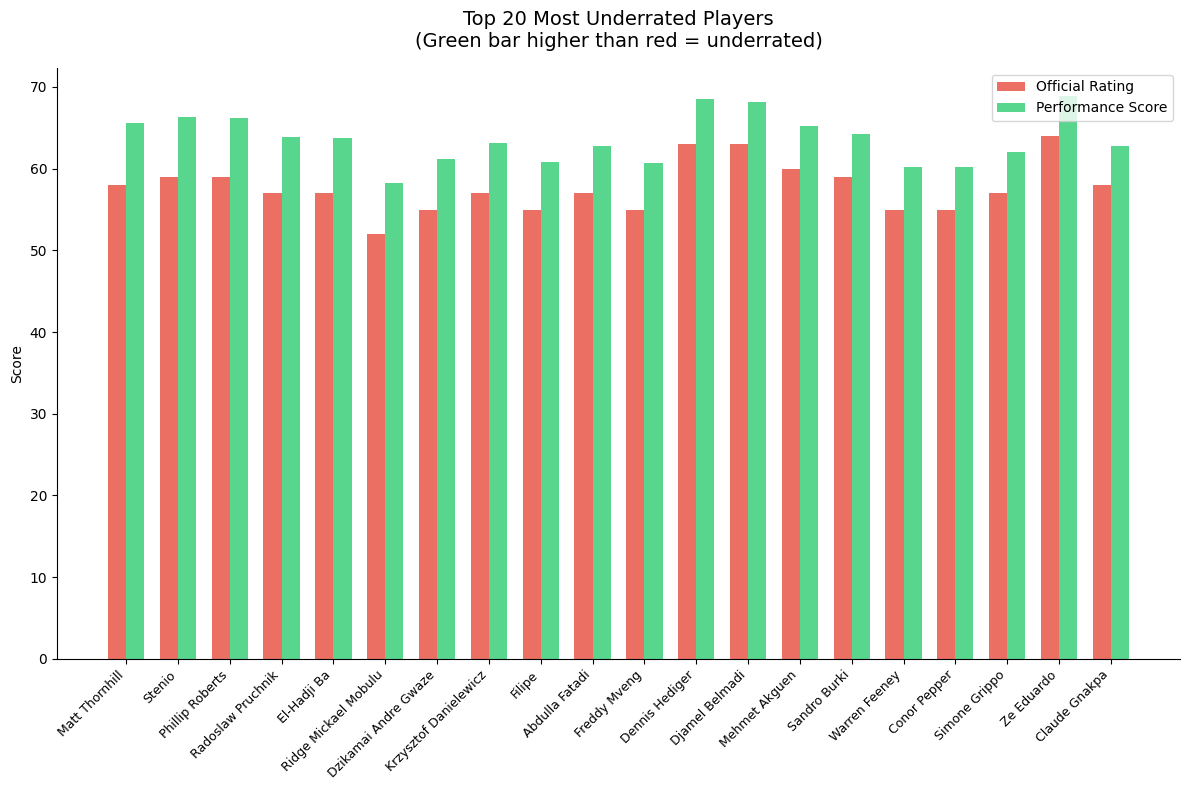

Chart saved!


In [4]:
# Get top 20 underrated players
top_underrated = result.nlargest(20, 'underrated_score')

fig, ax = plt.subplots(figsize=(12, 8))

x = range(len(top_underrated))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top_underrated['overall_rating'], 
               width, label='Official Rating', color='#e74c3c', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], top_underrated['performance_score'], 
               width, label='Performance Score', color='#2ecc71', alpha=0.8)

ax.set_title('Top 20 Most Underrated Players\n(Green bar higher than red = underrated)', 
             fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(top_underrated['player_name'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.legend()

plt.tight_layout()
plt.savefig('underrated_players.png', dpi=150)
plt.show()
print("Chart saved!")

In [5]:
# Add a label column
def label_player(score):
    if score >= 5:
        return '🔥 Highly Underrated'
    elif score >= 2:
        return '⭐ Underrated'
    elif score >= -2:
        return '✅ Fairly Rated'
    else:
        return '📉 Overrated'

result['verdict'] = result['underrated_score'].apply(label_player)

# Show top 20 underrated
top20 = result.nlargest(20, 'underrated_score')[
    ['player_name', 'overall_rating', 'performance_score', 'underrated_score', 'verdict']
]

print("TOP 20 MOST UNDERRATED PLAYERS")
print("=" * 65)
print(top20.to_string(index=False))

# Show top 10 overrated
bottom10 = result.nsmallest(10, 'underrated_score')[
    ['player_name', 'overall_rating', 'performance_score', 'underrated_score', 'verdict']
]

print("\nTOP 10 MOST OVERRATED PLAYERS")
print("=" * 65)
print(bottom10.to_string(index=False))

TOP 20 MOST UNDERRATED PLAYERS
          player_name  overall_rating  performance_score  underrated_score             verdict
       Matt Thornhill            58.0               65.6               7.6 🔥 Highly Underrated
               Stenio            59.0               66.3               7.3 🔥 Highly Underrated
      Phillip Roberts            59.0               66.2               7.2 🔥 Highly Underrated
    Radoslaw Pruchnik            57.0               63.9               6.9 🔥 Highly Underrated
          El-Hadji Ba            57.0               63.7               6.7 🔥 Highly Underrated
 Ridge Mickael Mobulu            52.0               58.3               6.3 🔥 Highly Underrated
 Dzikamai Andre Gwaze            55.0               61.2               6.2 🔥 Highly Underrated
Krzysztof Danielewicz            57.0               63.1               6.1 🔥 Highly Underrated
               Filipe            55.0               60.8               5.8 🔥 Highly Underrated
       Abdulla Fata

In [6]:
# Save results
result.to_csv('underrated_players.csv', index=False)
print("Saved!")

# Quick stats summary
print(f"\nTotal players analyzed: {len(result)}")
print(f"Highly underrated (5+): {len(result[result['underrated_score'] >= 5])}")
print(f"Underrated (2-5): {len(result[(result['underrated_score'] >= 2) & (result['underrated_score'] < 5)])}")
print(f"Fairly rated (-2 to 2): {len(result[(result['underrated_score'] >= -2) & (result['underrated_score'] < 2)])}")
print(f"Overrated (below -2): {len(result[result['underrated_score'] < -2])}")

Saved!

Total players analyzed: 11060
Highly underrated (5+): 18
Underrated (2-5): 245
Fairly rated (-2 to 2): 3301
Overrated (below -2): 7496
